In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('data/superstore.csv', encoding='latin-1')

print(df.shape)
print(df.columns.tolist())
df.head()

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#df.isnull().sum()
#df.duplicated().sum()
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [6]:
df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Delivery Days']].head()

,Order Date,Ship Date,Order Year,Order Month,Delivery Days
0,2016-11-08,2016-11-11,2016,11,3
1,2016-11-08,2016-11-11,2016,11,3
2,2016-06-12,2016-06-16,2016,6,4
3,2015-10-11,2015-10-18,2015,10,7
4,2015-10-11,2015-10-18,2015,10,7


In [7]:
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Orders: 5,009
Total Customers: 793
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%


In [8]:
yearly_sales = df.groupby('Order Year')['Sales'].sum()
yearly_profit = df.groupby('Order Year')['Profit'].sum()

print(yearly_sales)
print(yearly_profit)


Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64
Order Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


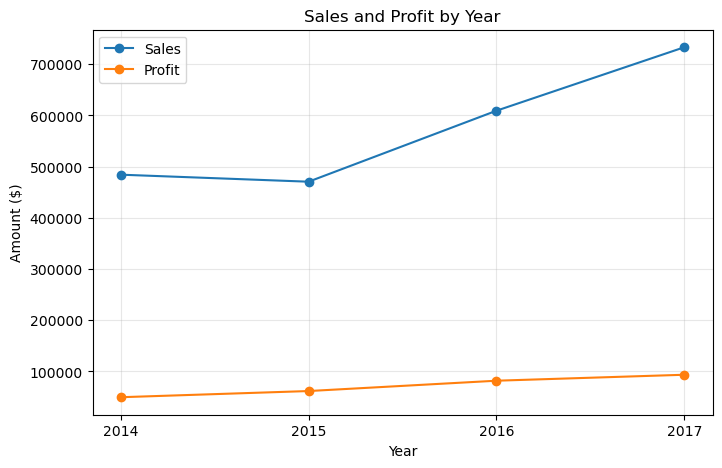

In [9]:
plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', label='Sales')
plt.plot(yearly_profit.index, yearly_profit.values, marker='o', label='Profit')
plt.title('Sales and Profit by Year')
plt.xlabel('Year')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(yearly_sales.index)
plt.savefig('charts/yearly_trend.png')
plt.show()

In [10]:
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
)

category_summary['Profit_Margin'] = (category_summary['Total_Profit'] / category_summary['Total_Sales']) * 100

print(category_summary)

                 Total_Sales  Total_Profit  Order_Count  Profit_Margin
Category                                                              
Furniture        741999.7953    18451.2728         1764       2.486695
Office Supplies  719047.0320   122490.8008         3742      17.035158
Technology       836154.0330   145454.9481         1544      17.395712


In [11]:
discount_by_category = df.groupby('Category')['Discount'].mean()
print(discount_by_category)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64


In [12]:
furniture_subcat = df[df['Category'] == 'Furniture'].groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
)
furniture_subcat['Profit_Margin'] = (furniture_subcat['Total_Profit'] / furniture_subcat['Total_Sales']) * 100

print(furniture_subcat)

              Total_Sales  Total_Profit  Avg_Discount  Profit_Margin
Sub-Category                                                        
Bookcases     114879.9963    -3472.5560      0.211140      -3.022768
Chairs        328449.1030    26590.1663      0.170178       8.095673
Furnishings    91705.1640    13059.1436      0.138349      14.240358
Tables        206965.5320   -17725.4811      0.261285      -8.564460


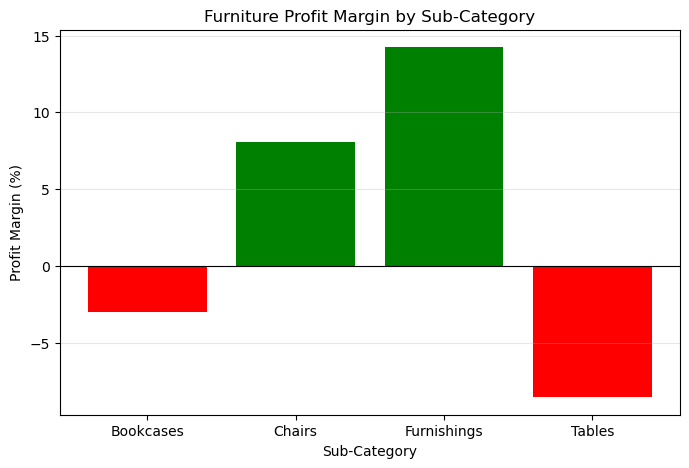

In [13]:
plt.figure(figsize=(8,5))

colors = ['red' if x < 0 else 'green' for x in furniture_subcat['Profit_Margin']]
plt.bar(furniture_subcat.index, furniture_subcat['Profit_Margin'], color=colors)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Furniture Profit Margin by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit Margin (%)')
plt.grid(True, alpha=0.3, axis='y')

plt.savefig('charts/furniture_subcategory_margin.png')
plt.show()

Calculate regional performance

In [14]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
)
region_summary['Profit_Margin'] = (region_summary['Total_Profit'] / region_summary['Total_Sales']) * 100

print(region_summary)

         Total_Sales  Total_Profit  Order_Count  Profit_Margin
Region                                                        
Central  501239.8908    39706.3625         1175       7.921629
East     678781.2400    91522.7800         1401      13.483399
South    391721.9050    46749.4303          822      11.934342
West     725457.8245   108418.4489         1611      14.944831


Dig into region category data

In [15]:
region_category = df.groupby(['Region', 'Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)
region_category['Profit_Margin'] = (region_category['Total_Profit'] / region_category['Total_Sales']) * 100

print(region_category)

                         Total_Sales  Total_Profit  Profit_Margin
Region  Category                                                 
Central Furniture        163797.1638    -2871.0494      -1.752808
        Office Supplies  167026.4150     8879.9799       5.316512
        Technology       170416.3120    33697.4320      19.773595
East    Furniture        208291.2040     3046.1658       1.462455
        Office Supplies  205516.0550    41014.5791      19.956873
        Technology       264973.9810    47462.0351      17.911961
South   Furniture        117298.6840     6771.2061       5.772619
        Office Supplies  125651.3130    19986.3928      15.906235
        Technology       148771.9080    19991.8314      13.437908
West    Furniture        252612.7435    11504.9503       4.554382
        Office Supplies  220853.2490    52609.8490      23.821180
        Technology       251991.8320    44303.6496      17.581383
